In [1]:
import sys
import time

import pandas as pd
import numpy as np
from itertools import combinations
from shap import Explanation
import sys
import torch
import math
import random
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import math
import xgboost
import shap
import time
import itertools
from weighted_shapley import Weighted_Shapley
import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)

In [2]:
x1 =np.random.normal(0, 1, size=(10000, 1)) 
x2 = 0.01 *np.random.normal(0, 1, size=(10000, 1)) + 0.99995*x1
x3 = np.random.normal(0, 1, size=(10000, 1))
x6 = 0.57 * np.random.normal(0, 1, size=(10000, 1))  + 0.57 * x2 + 0.57 *x3
# x4 = np.random.normal(0, 1, size=(10000, 1)) 
# x5 = 0.57 * np.random.normal(0, 1, size=(10000, 1))  + 0.57 * x6 + 0.57 *x4
arr = np.hstack((x1, x2, x3,  x6))
pd_data = pd.DataFrame(arr, columns=["x1", "x2", "x3", "x6"])
pd_data = (pd_data-pd_data.mean())/pd_data.std()
X = pd_data[["x1", "x2", "x3"]]
y = pd_data["x6"]

In [3]:
lr = LinearRegression()
lr.fit(X, y)
w = lr.coef_[0]

In [4]:
lr.coef_

array([-1.00043314,  1.57067934,  0.57873379])

In [5]:
# oracle = {'x1': {frozenset({'x2'}), frozenset({'x2', 'x3'})}, 
#            'x3': set(),
#           'x2': set(),
#           }
import itertools
oracle = {}
s = [ 'x3']
all_subsets = [subset for i in range(len(s)+1) for subset in itertools.combinations(s, i)]
def findsubsets(s, n):
    return list(itertools.combinations(s, n))
sets = {frozenset({'x2'}.union(set(s))) for s in all_subsets}
oracle['x1'] = sets
#oracle['x1'] = sets.union(x22)
oracle['x2'] = set()
oracle['x3'] = set()
print(oracle)
s = ['x2', 'x3', 'x1']
all_subsets = [subset for i in range(len(s)+1) for subset in itertools.combinations(s, i)]
#print(all_subsets)

from weighted_shapley import Weighted_Shapley
sh = Weighted_Shapley(X, y, lr, 3)
print(f'X.iloc[3]: {X.iloc[3]}')
print(f'lr.coef is {lr.coef_}')
q = sh.find_shapley(X.iloc[3], explanation_type="standard", sparsest_oracle=oracle)
a, b, c = sh.find_shapley(X.iloc[3], explanation_type="markov blanket/sparsest/standard", sparsest_oracle=oracle)
#b = sh.find_shapley(X.iloc[3], explanation_type="sparsest", sparsest_oracle=oracle)

{'x1': {frozenset({'x2', 'x3'}), frozenset({'x2'})}, 'x2': set(), 'x3': set()}
X.iloc[3]: x1    2.287681
x2    2.289563
x3    0.435052
Name: 3, dtype: float64
lr.coef is [-1.00043314  1.57067934  0.57873379]
 data point type is :<class 'pandas.core.series.Series'>
3
one done!
 data point type is :<class 'pandas.core.series.Series'>
3
 data point type is :<class 'pandas.core.series.Series'>
3
 data point type is :<class 'pandas.core.series.Series'>
3


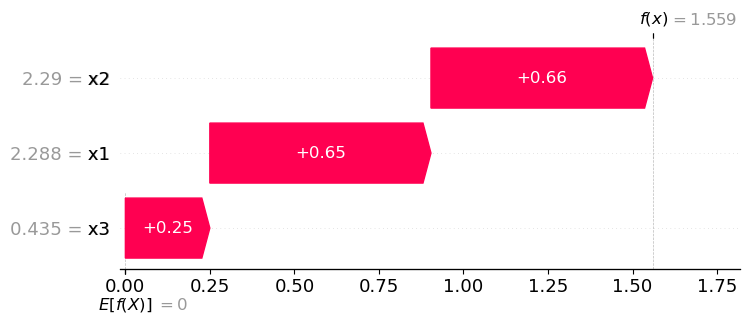

In [8]:
shap.waterfall_plot(q)

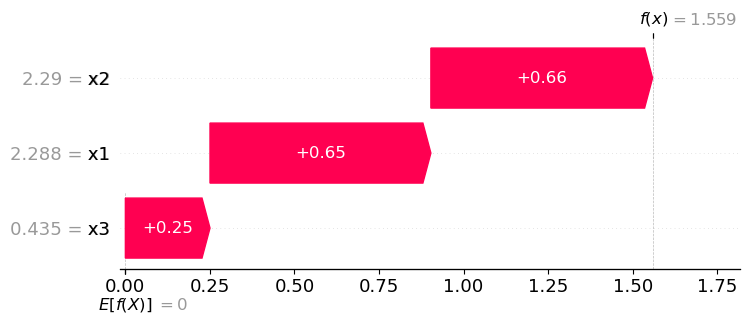

In [6]:
shap.waterfall_plot(a)

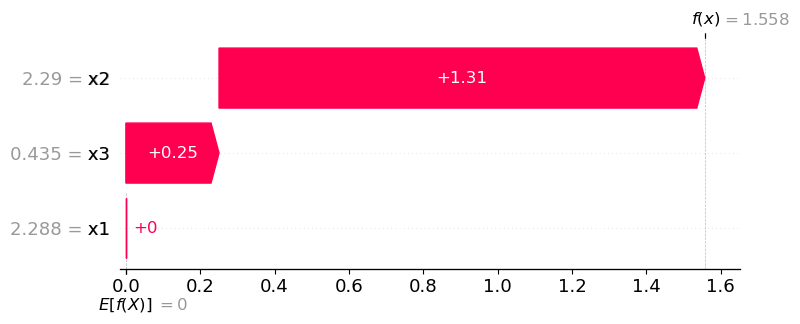

In [7]:
shap.waterfall_plot(b)


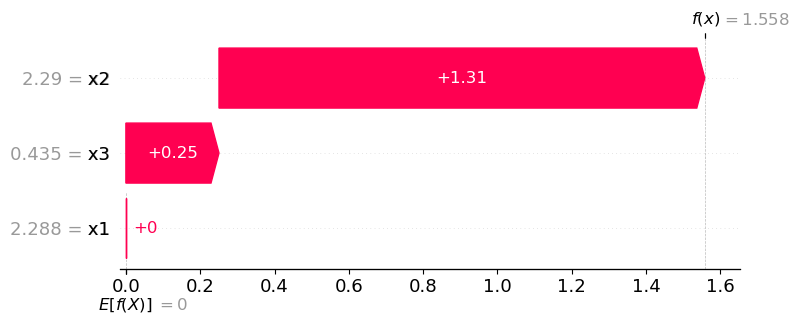

In [8]:
shap.waterfall_plot(c)